# Music Composition

## Importing Libraries

In [1]:
import os
import keras
from keras import layers
import numpy as np
import pandas as pd
from collections import Counter
import random
from IPython.display import Image, Audio
from music21 import *
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
np.random.seed(42)

## Helping functions

In [2]:
def extract_notes(file):
    notes = []
    pick = None
    for j in file:
        songs = instrument.partitionByInstrument(j)
        for part in songs.parts:
            pick = part.recurse()
            for element in pick:
                if isinstance(element, note.Note):
                    notes.append(str(element.pitch))
                elif isinstance(element, chord.Chord):
                    notes.append(".".join(str(n) for n in element.normalOrder))
    return notes

def show(music):
    display(Image(str(music.write("lily.png"))))

def chords_n_notes(Snippet):
    Melody = []
    offset = 0
    for i in Snippet:
        if ("." in i or i.isdigit()):
            chord_notes = i.split(".") 
            notes = []
            for j in chord_notes:
                inst_note=int(j)
                note_snip = note.Note(inst_note)
                notes.append(note_snip)
                chord_snip = chord.Chord(notes)
                chord_snip.offset = offset
                Melody.append(chord_snip)
        else:
            note_snip = note.Note(i)
            note_snip.offset = offset
            Melody.append(note_snip)
        offset += 1
    Melody_midi = stream.Stream(Melody)
    return Melody_midi

def get_temperature_scaled_probs(model, input_seq, temperature=1.0):
    preds = model.predict(input_seq, verbose=0)[0]
    preds = np.asarray(preds).astype('float64')

    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    probs = exp_preds / np.sum(exp_preds)

    return probs


def song_generator(model, data, song_len, seq_length, notes_map, temperature=1.0):
    seed_idx = np.random.randint(0, len(data))
    seed = data[seed_idx].astype(np.int32).copy()

    generated_tokens = []

    for _ in range(song_len):
        input_seq = seed.reshape(1, seq_length)
        probs = get_temperature_scaled_probs(model, input_seq, temperature)

        next_index = np.random.choice(len(probs), p=probs)
        generated_tokens.append(next_index)
        seed = np.append(seed[1:], next_index)

    music_tokens = [notes_map[i] for i in generated_tokens]
    melody_stream = chords_n_notes(music_tokens)

    return music_tokens, melody_stream


def plot_probabilities(model, unique_corpus, top_n=10, note_idx=None, temperatures=None):
    if temperatures is None:
        temperatures = [1.0]
    if note_idx is None:
        note_idx = random.randint(0, len(unique_corpus) - 1)

    all_data = []

    for temp in temperatures:
        input_seq = np.zeros((1, 40), dtype=np.int32)
        input_seq[0, -1] = note_idx

        probs = get_temperature_scaled_probs(model, input_seq, temperature=temp)

        top_indices = np.argsort(probs)[-top_n:][::-1]
        top_probs = probs[top_indices]
        top_notes = [unique_corpus[i] for i in top_indices]

        for note, prob in zip(top_notes, top_probs):
            all_data.append({
                'Note': note,
                'Probability': prob,
                'Temperature': temp
            })

    df = pd.DataFrame(all_data)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x='Note', y='Probability', hue='Temperature', palette='deep')
    plt.title(f'Top {top_n} Predicted Notes for Different Temperatures')
    plt.ylabel('Probability')
    plt.xlabel('Notes')
    plt.legend(title='Temperature')
    plt.tight_layout()
    plt.show()


## Loading data

In [3]:
filepath_lofi = "./Lofi/"

lofi_midis= []
for i in os.listdir(filepath_lofi):
    if i.endswith(".mid"):
        tr = filepath_lofi+i
        midi = converter.parse(tr)
        lofi_midis.append(midi)

filepath_OcOT = "./Ocarina-of-time/"
OcOT_midis= []
for i in os.listdir(filepath_OcOT):
    if i.endswith(".mid"):
        tr = filepath_OcOT+i
        midi = converter.parse(tr)
        OcOT_midis.append(midi)

lofi_corpus = extract_notes(lofi_midis)
OcOT_corpus = extract_notes(OcOT_midis)
Corpus = lofi_corpus + OcOT_corpus
print ("Lofi Corpus Length:", len(lofi_corpus))
print ("OcOT Corpus Length:", len(OcOT_corpus))
print ("Combined Corpus Length:", len(Corpus))
print("Values in Corpus", Corpus[:25], Corpus[-25:])

Lofi Corpus Length: 2046
OcOT Corpus Length: 179561
Combined Corpus Length: 181607
Values in Corpus ['6.9.11.1.2', '6.9.11.2', '11.2.4.7', '1.2.4.6.9', '6.9.11.1.2', '6.9.11.2', '11.2.4.7', '1.2.4.6.9', '6.9.11.1.2', '9.11.0.2.4', 'E4', 'G4', 'E5', '11.2.4.6.7', 'F#4', 'E5', 'B4', 'G5', '9.11.0.2.4', 'E4', 'G4', 'E5', '11.2.4.6.7', 'F#4', 'E5'] ['2.7', '2.6', '11.2', '11.4', '11.4', '9.2', '9.2', '8.1', '9.2', '7.0', '8.1', 'B4', '7.0', 'F#5', '9.11.0', 'D5', '4.5.7', 'A5', 'D5', 'A5', '8.1', '7.0', '8.1', '6.11', '7.0']


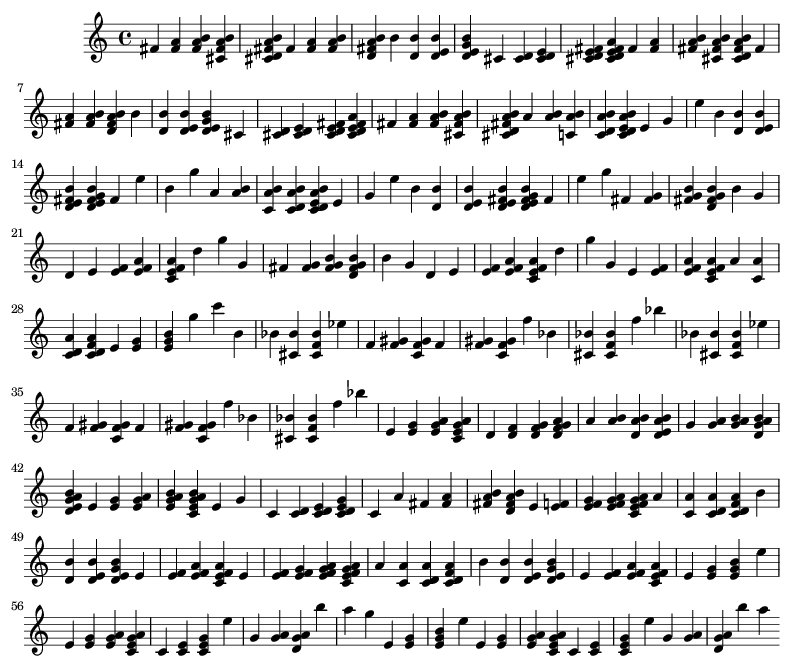

In [4]:
musical_sheet = chords_n_notes(Corpus[:100])
show(musical_sheet)

### Data exploration

In [5]:
counter_lofi=Counter(lofi_corpus)
counter_OcOT=Counter(OcOT_corpus)
counter_Corpus=Counter(Corpus)

print("Total unique notes in the Lofi Corpus:", len(counter_lofi))
print("Total unique notes in the OcOt Corpus:", len(counter_OcOT))
print("Total unique notes in the Corpus:", len(counter_Corpus))

Total unique notes in the Lofi Corpus: 258
Total unique notes in the OcOt Corpus: 490
Total unique notes in the Corpus: 548


In [6]:
print("Most common notes in the Corpus:", counter_Corpus.most_common(10))

Most common notes in the Corpus: [('9.11', 9826), ('11', 6489), ('F#4', 6356), ('B4', 5188), ('6', 5186), ('A4', 4835), ('C3', 4462), ('D5', 4281), ('D4', 4243), ('E4', 4078)]


In [7]:
print("Least common notes in the Corpus:", counter_Corpus.most_common()[-10:])

Least common notes in the Corpus: [('4.7.9.11', 1), ('5.6.7.9.11', 1), ('4.6.8.9.11.0', 1), ('6.7.8.9.11.2', 1), ('2.4.6.7.8.11', 1), ('4.5.6.9.0', 1), ('2.5.6.9.10', 1), ('2.5.6.7.8.9.10', 1), ('4.7.8.9.11', 1), ('8.9.0', 1)]


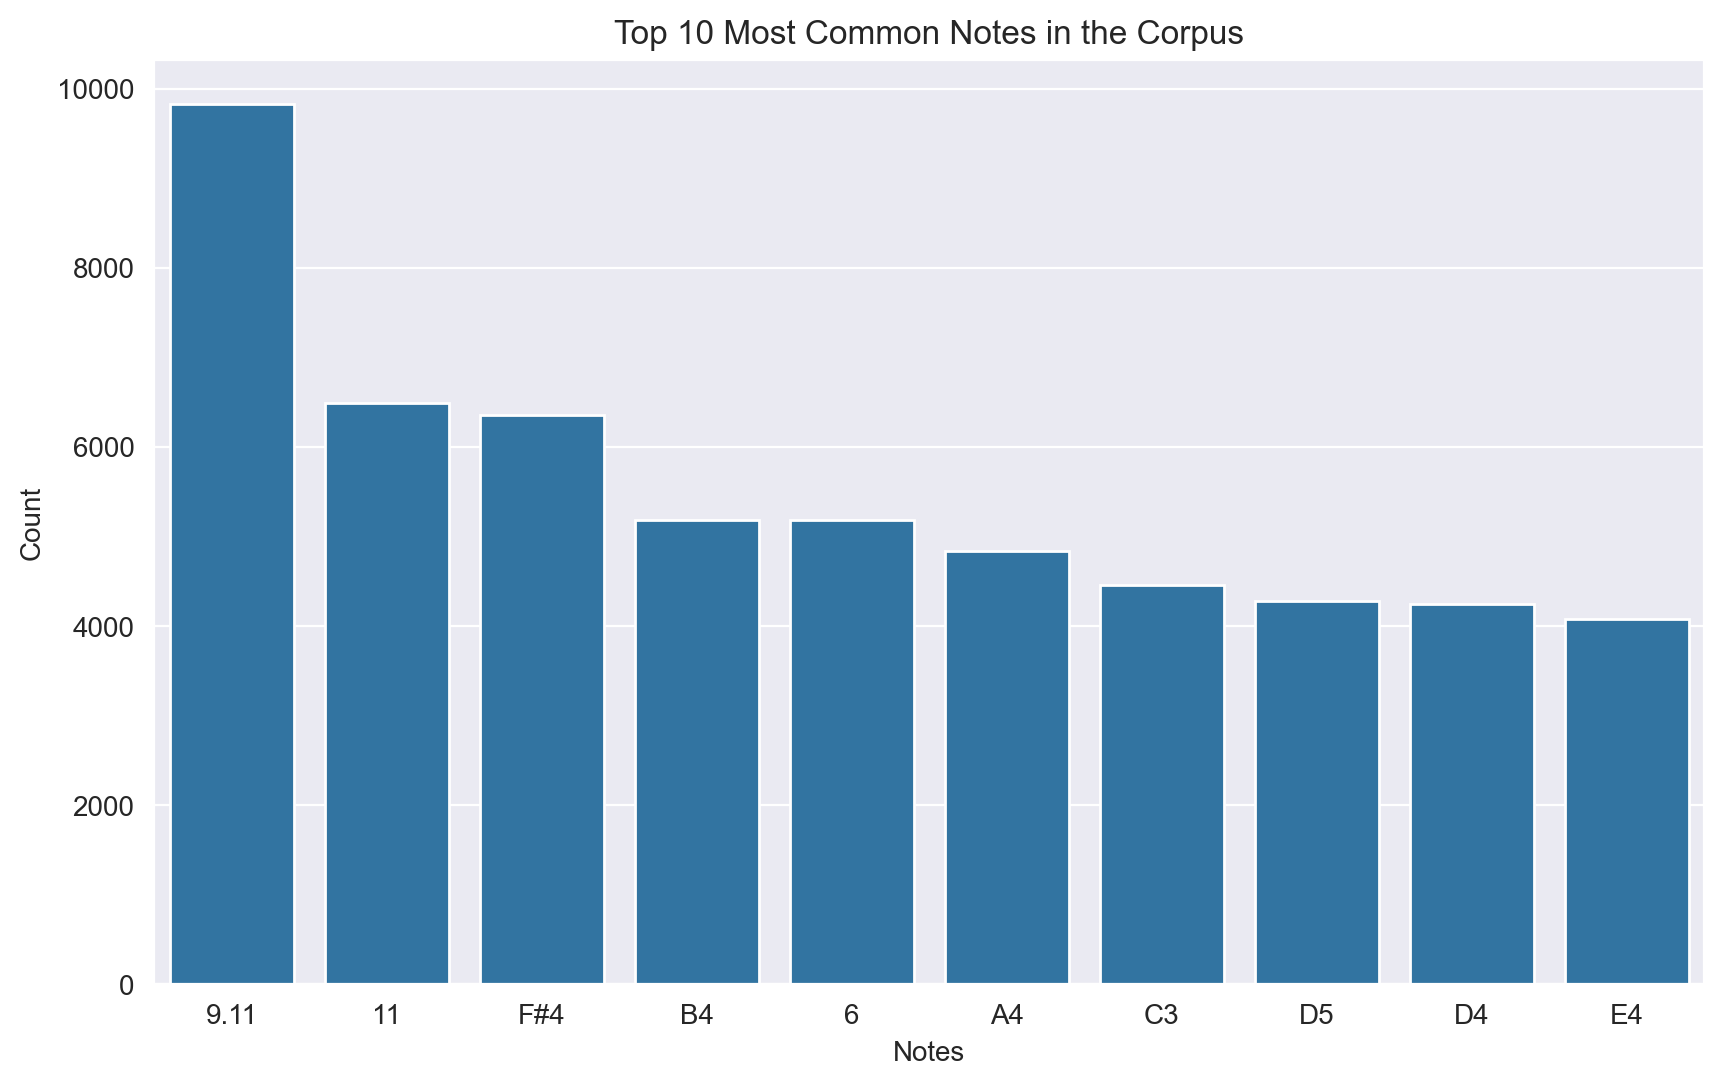

In [8]:
# Plotting the most common notes
most_common_notes = counter_Corpus.most_common(10)
notes, counts = zip(*most_common_notes)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(notes), y=list(counts))
plt.title('Top 10 Most Common Notes in the Corpus')
plt.ylabel('Count')
plt.xlabel('Notes')
plt.show()

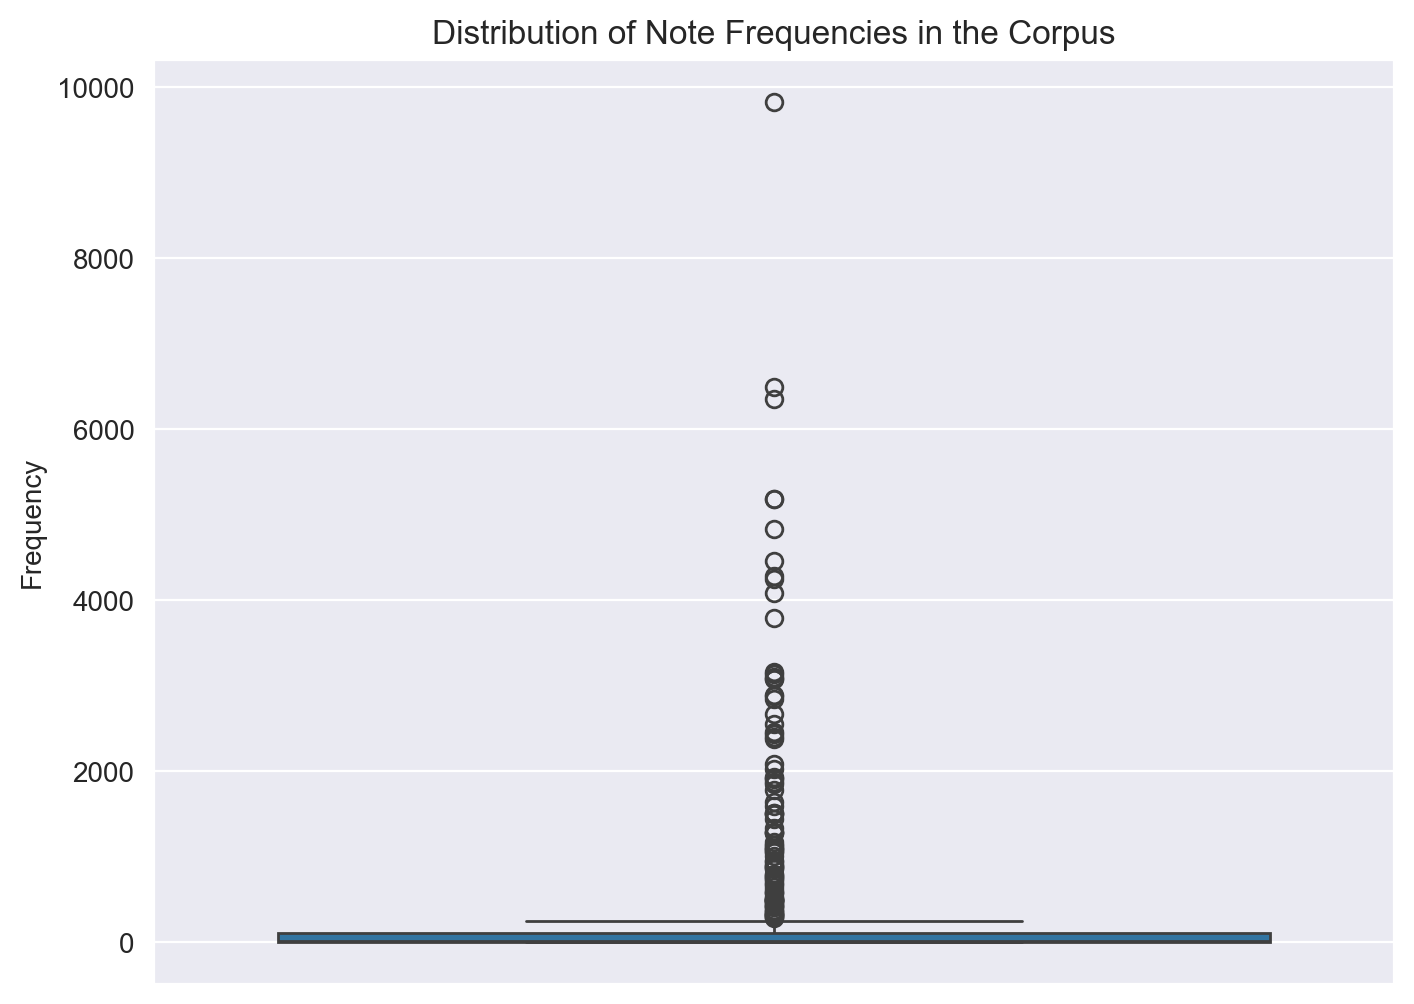

In [9]:
# boxplot to show distribution of note frequencies
plt.figure(figsize=(8, 6))
sns.boxplot(data=list(counter_Corpus.values()))
plt.title('Distribution of Note Frequencies in the Corpus')
plt.ylabel('Frequency')
plt.show()

In [10]:
print("Number of notes that appear only once in the Corpus:", sum(1 for count in counter_Corpus.values() if count == 1))

Number of notes that appear only once in the Corpus: 73


### Data preprocessing

In [11]:
unique_corpus = sorted(list(set(Corpus)))

print("Total number of characters:", len(Corpus))
print("Number of unique characters:", len(unique_corpus))

Total number of characters: 181607
Number of unique characters: 548


In [12]:
mapping = dict((c, i) for i, c in enumerate(unique_corpus))
reverse_mapping = dict((i, c) for i, c in enumerate(unique_corpus))

print(mapping)

{'0': 0, '0.1': 1, '0.1.2': 2, '0.1.2.3.4.5.6.7.8.9.10': 3, '0.1.2.3.4.5.7.8.10': 4, '0.1.3.5.8': 5, '0.1.4': 6, '0.1.5': 7, '0.1.5.8': 8, '0.2': 9, '0.2.3': 10, '0.2.3.5.7': 11, '0.2.3.7': 12, '0.2.4': 13, '0.2.4.5': 14, '0.2.4.6': 15, '0.2.4.7': 16, '0.2.4.7.9': 17, '0.2.5': 18, '0.2.6': 19, '0.2.7': 20, '0.3': 21, '0.3.4': 22, '0.3.5': 23, '0.3.5.7': 24, '0.3.5.7.8': 25, '0.3.5.8': 26, '0.3.7': 27, '0.4': 28, '0.4.5': 29, '0.4.5.6': 30, '0.4.5.7': 31, '0.4.6': 32, '0.4.7': 33, '0.5': 34, '0.5.6': 35, '0.6': 36, '1': 37, '1.2': 38, '1.2.3.4.5.6.7.8.9.10.11': 39, '1.2.3.4.5.6.8.9.11': 40, '1.2.4.6.9': 41, '1.2.6': 42, '1.2.6.9': 43, '1.2.7': 44, '1.3': 45, '1.3.4.8': 46, '1.3.5': 47, '1.3.5.7.10': 48, '1.3.8': 49, '1.4': 50, '1.4.6.8.9': 51, '1.4.6.9': 52, '1.4.7': 53, '1.4.7.9': 54, '1.4.8': 55, '1.5': 56, '1.5.6': 57, '1.5.8': 58, '1.6': 59, '1.7': 60, '10': 61, '10.0': 62, '10.0.1.5': 63, '10.0.2': 64, '10.0.2.4': 65, '10.0.2.5': 66, '10.0.2.5.7': 67, '10.0.3': 68, '10.0.4': 69, '1

In [13]:
length = 40
step = 1
features = []
targets = []
for i in range(0, len(Corpus) - length, step):
    feature = Corpus[i:i + length]
    target = Corpus[i + length]
    features.append([mapping[j] for j in feature])
    targets.append(mapping[target])
print("Number of features:", len(features))

Number of features: 181567


In [14]:
x = np.array(features, dtype=np.int32)
y = np.array(targets, dtype=np.int32)

In [15]:
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)

## Model building and training

In [43]:
batch_size = 128
corpus_len = len(unique_corpus)
epochs = 40

embed = keras.Sequential([
    layers.Embedding(input_dim = corpus_len, output_dim = 16)
])

optimizer = keras.optimizers.Nadam(learning_rate = 0.01)

lr = keras.callbacks.ReduceLROnPlateau(monitor = "val_loss", factor = 0.5, patience = 3)
es = keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 5, restore_best_weights = True)

### LSTM model

In [44]:
rnn = keras.Sequential([
    layers.LSTM(128),
    layers.Dense(corpus_len, activation = "softmax")
])

optimizer = keras.optimizers.Nadam(learning_rate = 0.01)

lstm_model = keras.Sequential([embed, rnn])
lstm_model.compile(loss = "sparse_categorical_crossentropy", optimizer = optimizer, metrics = ["accuracy"])
lstm_model.fit(x_train, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_valid, y_valid), callbacks = [es, lr])

Epoch 1/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - accuracy: 0.2702 - loss: 3.0892 - val_accuracy: 0.4876 - val_loss: 1.9627 - learning_rate: 0.0100
Epoch 2/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 35s 31ms/step - accuracy: 0.5198 - loss: 1.8190 - val_accuracy: 0.5610 - val_loss: 1.6915 - learning_rate: 0.0100
Epoch 3/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - accuracy: 0.5859 - loss: 1.5492 - val_accuracy: 0.5920 - val_loss: 1.5869 - learning_rate: 0.0100
Epoch 4/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - accuracy: 0.6176 - loss: 1.4110 - val_accuracy: 0.6171 - val_loss: 1.5167 - learning_rate: 0.0100
Epoch 5/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accuracy: 0.6390 - loss: 1.3454 - val_accuracy: 0.6127 - val_loss: 1.5338 - learning_rate: 0.0100
Epoch 6/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 35s 31ms/step - accuracy: 0.6393 - loss: 1.3432 - val_accuracy: 0.6205 - val_loss: 1.5344 - learning_rate: 0.0100
Epoch 7/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - accura

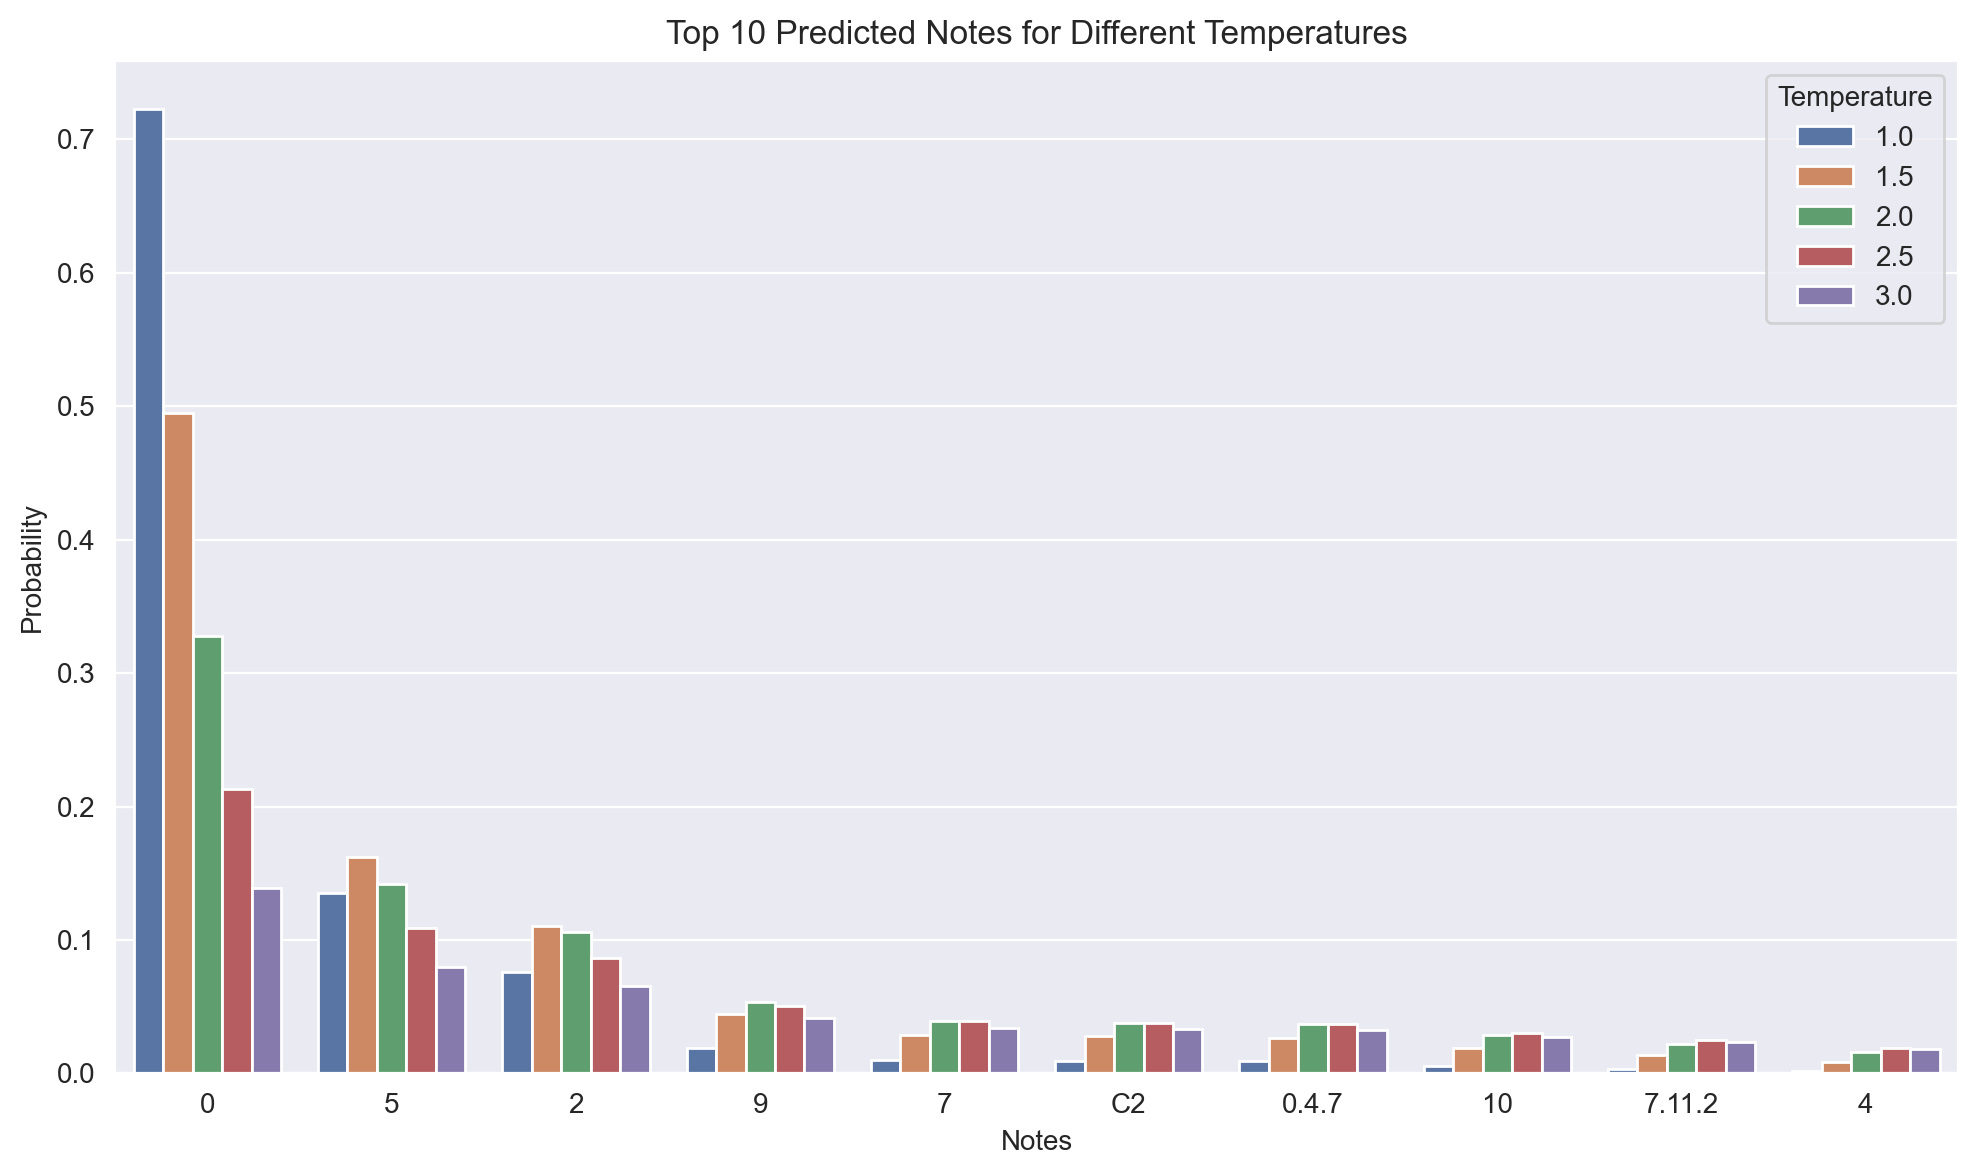

In [49]:
lstm_temperatures = gru_temperatures = [1.0, 1.5, 2.0, 2.5, 3.0]
plot_probabilities(lstm_model, unique_corpus, top_n=10, note_idx=0, temperatures=lstm_temperatures)

In [51]:
songs = {}
notes = {}
for temp in lstm_temperatures:
    song, note_stream = song_generator(lstm_model, x_valid, song_len=100, seq_length=40, notes_map=reverse_mapping, temperature=temp)
    songs[temp] = song
    notes[temp] = note_stream
    print(f"Generated song at temperature {temp}.")

Generated song at temperature 1.0.
Generated song at temperature 1.5.
Generated song at temperature 2.0.
Generated song at temperature 2.5.
Generated song at temperature 3.0.


Generated song at temperature 1.0:


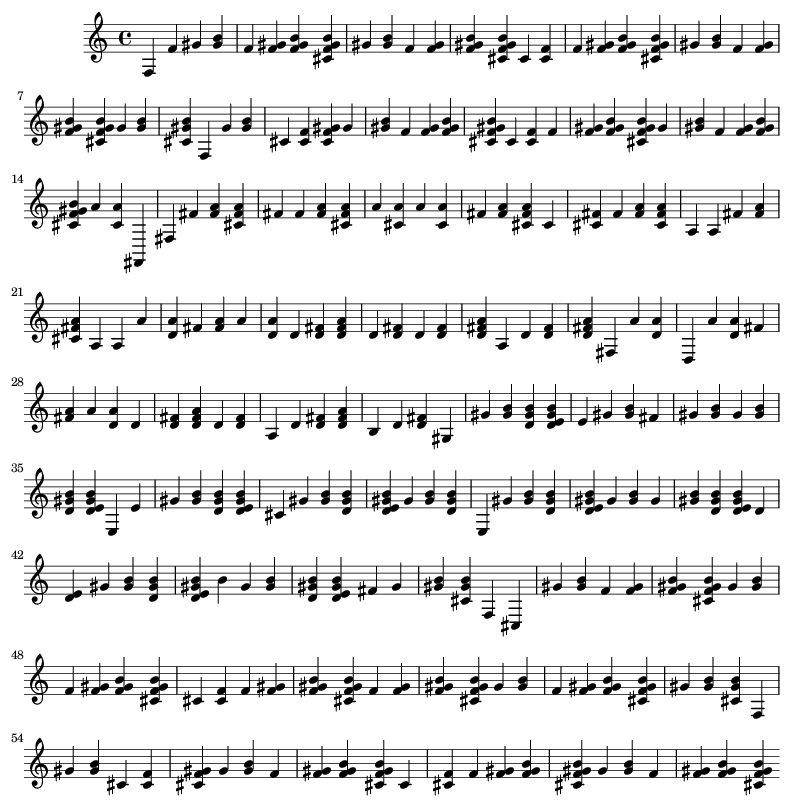

Generated song at temperature 1.5:


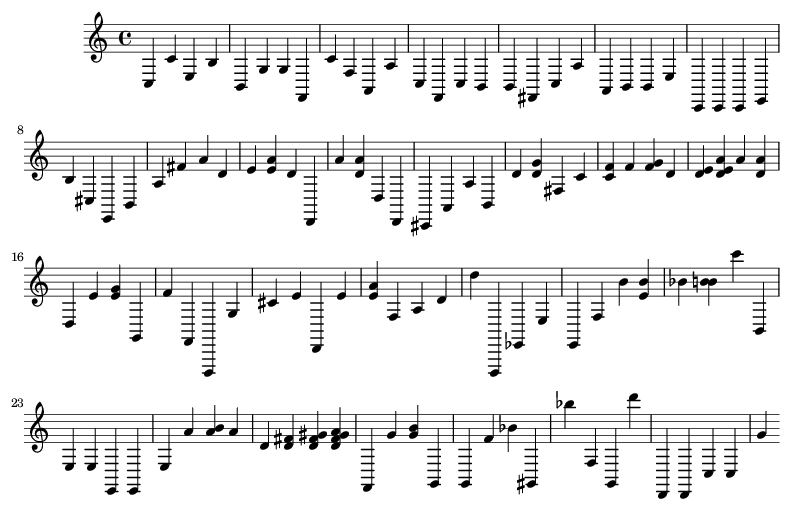

Generated song at temperature 2.0:


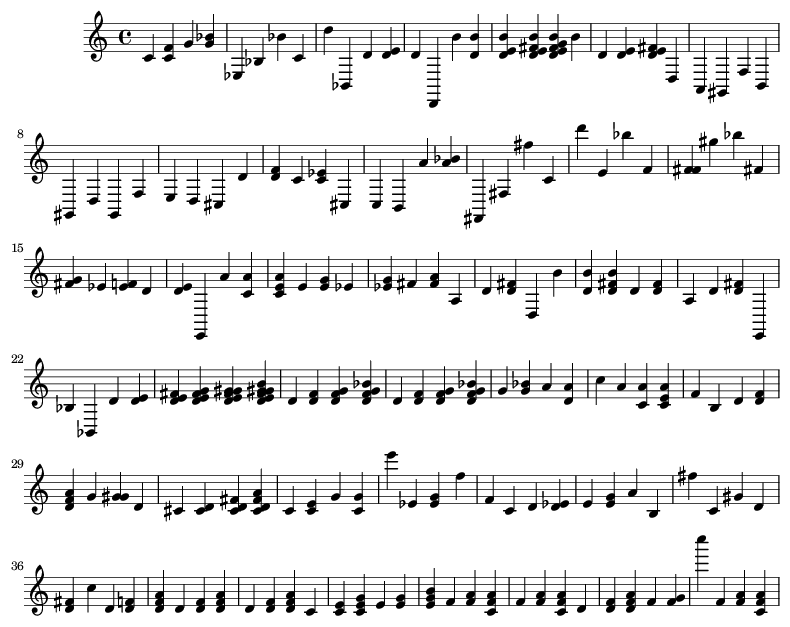

Generated song at temperature 2.5:


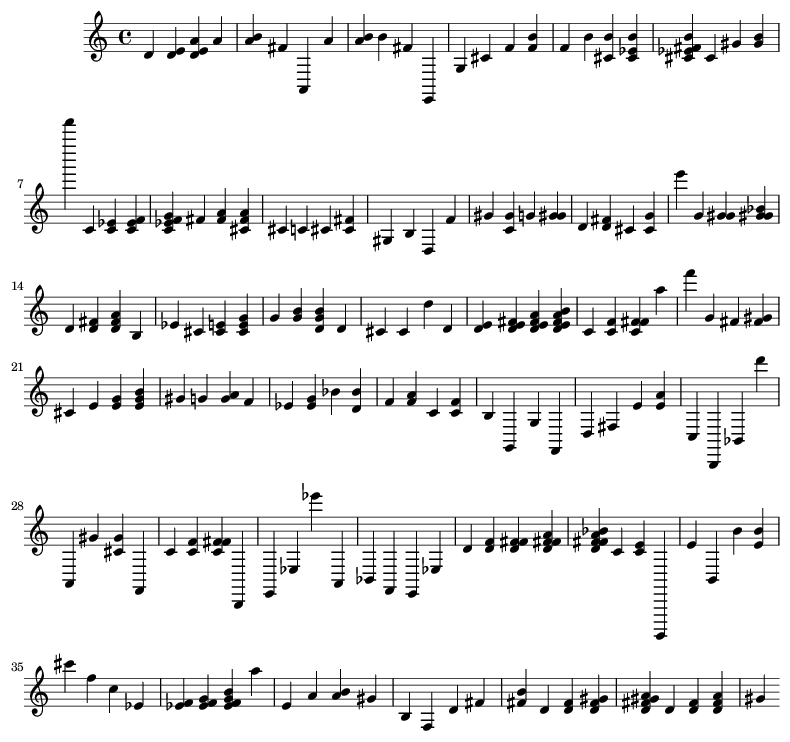

Generated song at temperature 3.0:


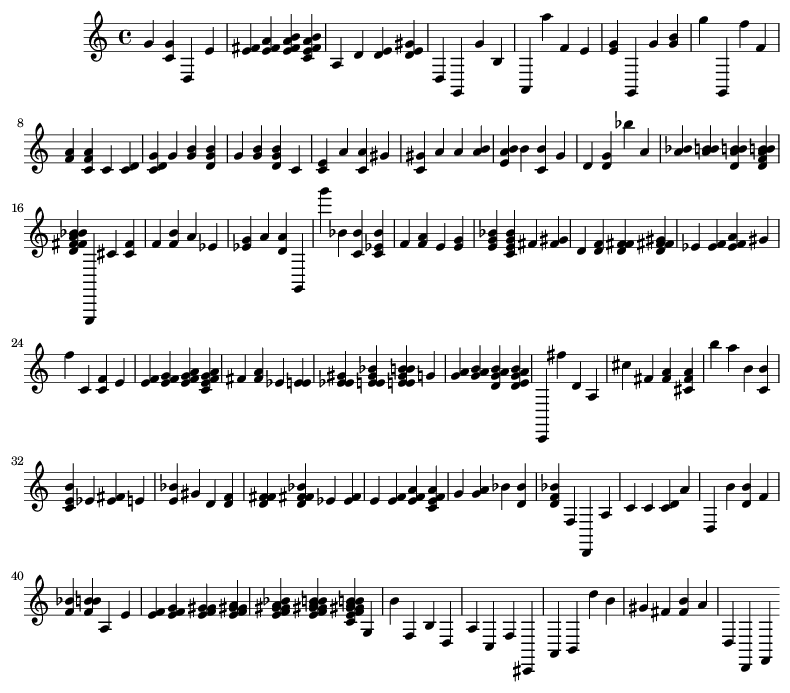

In [52]:
for temp in lstm_temperatures:
    print(f"Generated song at temperature {temp}:")
    notes[temp].write('midi', f'songs/lstm/LSTM_t{temp}.mid')
    show(notes[temp])

### GRU Model

In [21]:
rnn = keras.Sequential([
    layers.GRU(128),
    layers.Dense(corpus_len, activation = "softmax")
])

optimizer = keras.optimizers.Nadam(learning_rate = 0.01)

gru_model = keras.Sequential([embed, rnn])
gru_model.compile(loss = "sparse_categorical_crossentropy", optimizer = optimizer, metrics = ["accuracy"])
gru_model.fit(x_train, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_valid, y_valid), callbacks = [es, lr])

Epoch 1/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - accuracy: 0.3901 - loss: 2.4715 - val_accuracy: 0.5031 - val_loss: 1.9111 - learning_rate: 0.0100
Epoch 2/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 31s 27ms/step - accuracy: 0.4946 - loss: 1.9387 - val_accuracy: 0.2739 - val_loss: 3.5889 - learning_rate: 0.0100
Epoch 3/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.3033 - loss: 3.2082 - val_accuracy: 0.3392 - val_loss: 2.8982 - learning_rate: 0.0100
Epoch 4/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - accuracy: 0.3407 - loss: 2.8332 - val_accuracy: 0.3485 - val_loss: 2.8481 - learning_rate: 0.0100
Epoch 5/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - accuracy: 0.3683 - loss: 2.6531 - val_accuracy: 0.3811 - val_loss: 2.6378 - learning_rate: 0.0050
Epoch 6/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - accuracy: 0.3765 - loss: 2.5828 - val_accuracy: 0.3705 - val_loss: 2.6198 - learning_rate: 0.0050


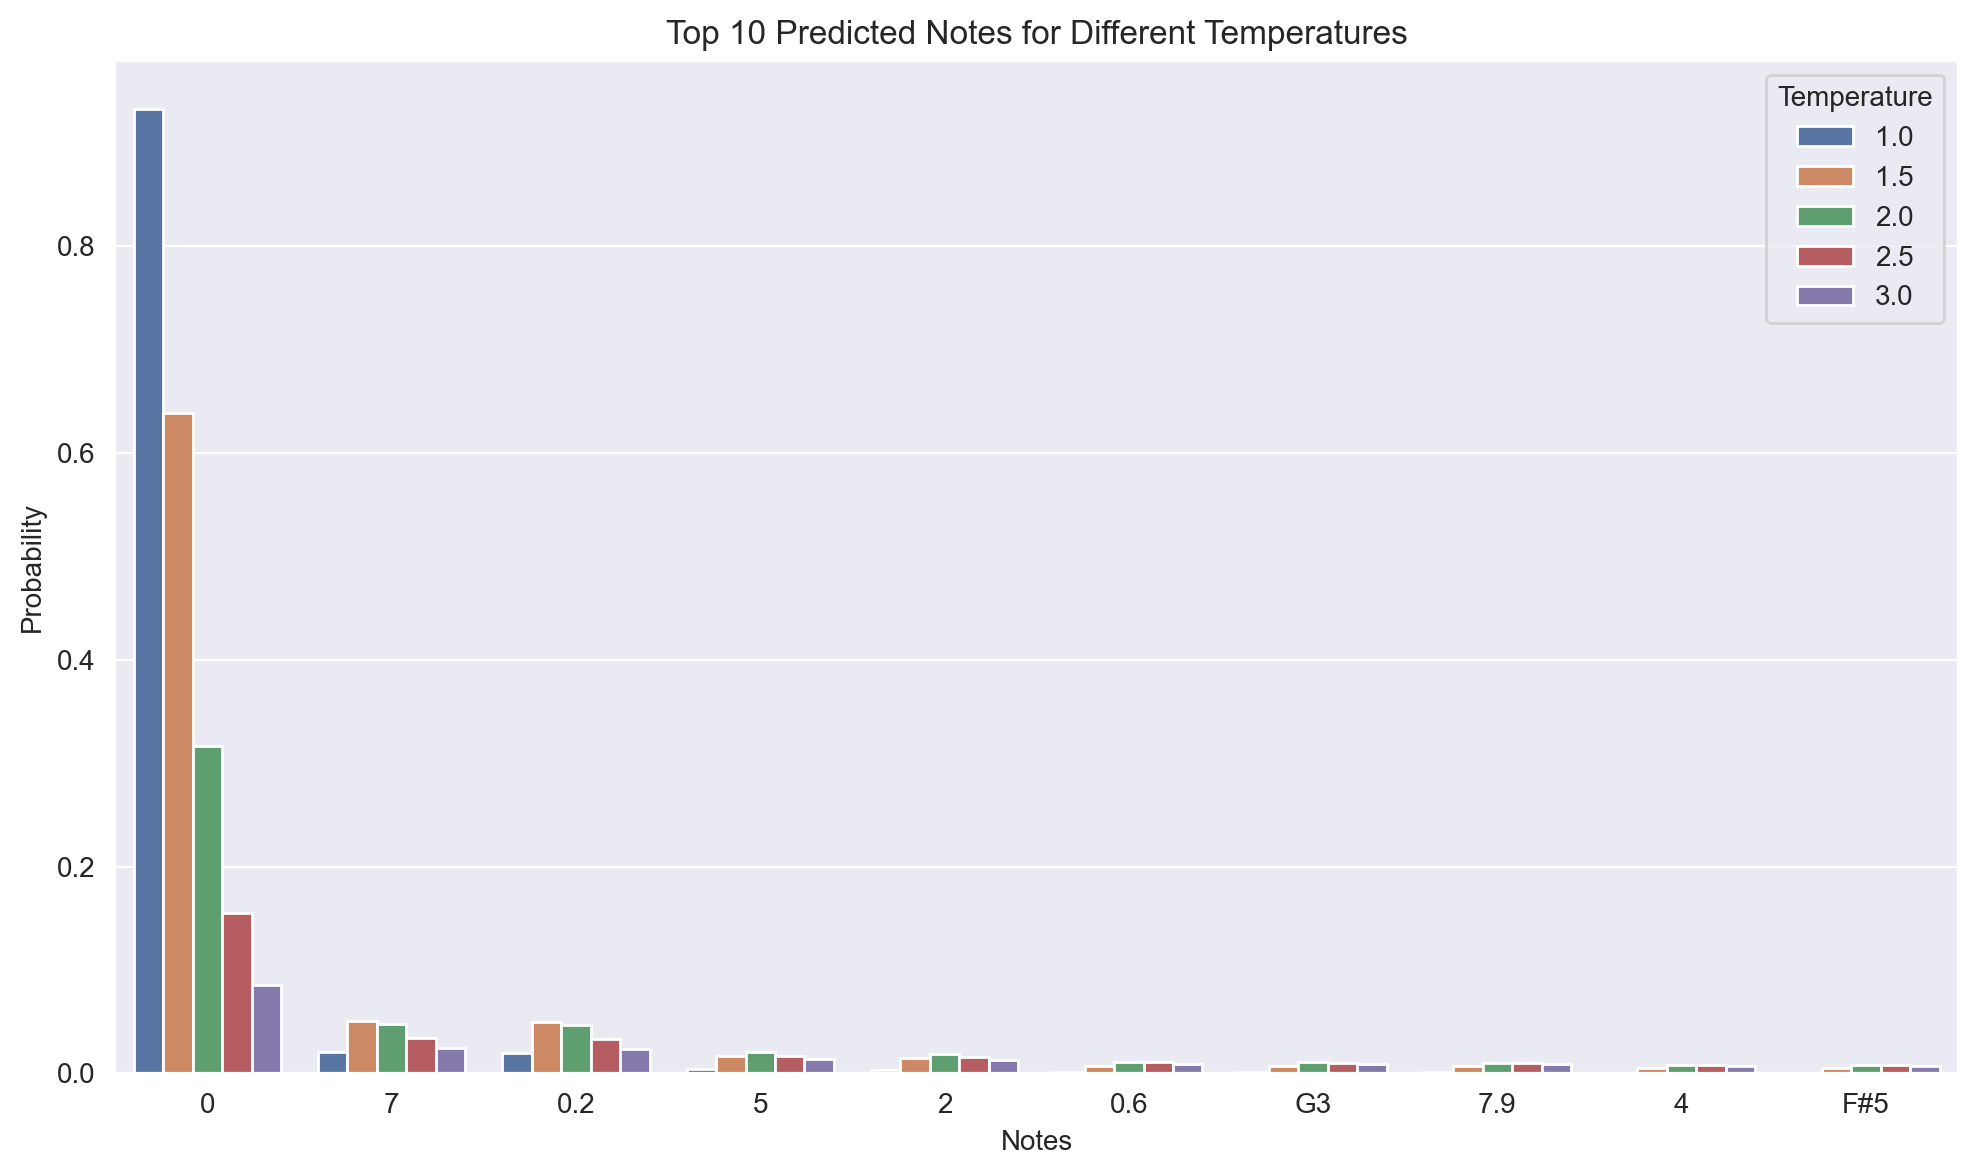

In [22]:
gru_temperatures = [1.0, 1.5, 2.0, 2.5, 3.0]
plot_probabilities(gru_model, unique_corpus, top_n=10, note_idx=0, temperatures=gru_temperatures)

In [26]:
songs = {}
notes = {}
for temp in gru_temperatures:
    song, note_stream = song_generator(gru_model, x_valid, song_len=100, seq_length=40, notes_map=reverse_mapping, temperature=temp)
    songs[temp] = song
    notes[temp] = note_stream
    print(f"Generated song at temperature {temp}.")

Generated song at temperature 1.0.
Generated song at temperature 1.5.
Generated song at temperature 2.0.
Generated song at temperature 2.5.
Generated song at temperature 3.0.


Generated song at temperature 1.0:


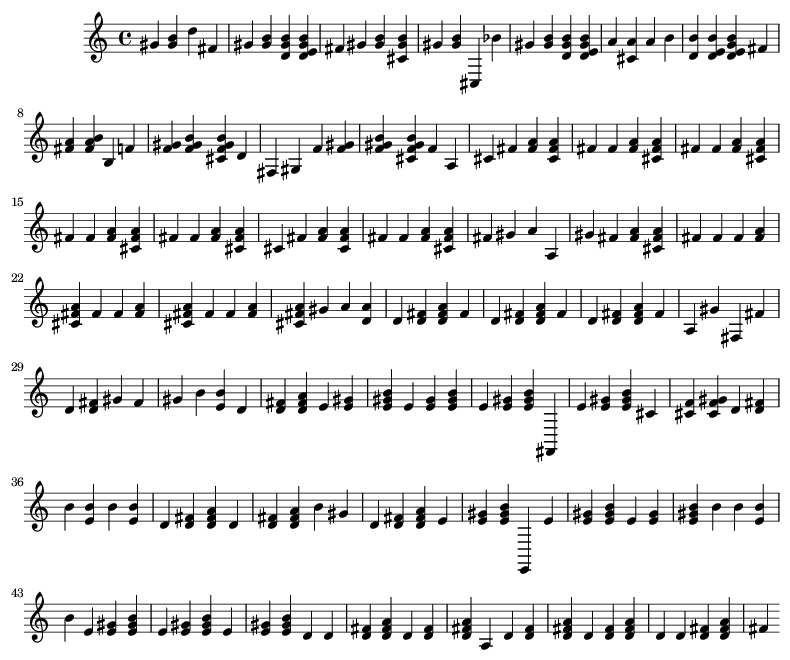

Generated song at temperature 1.5:


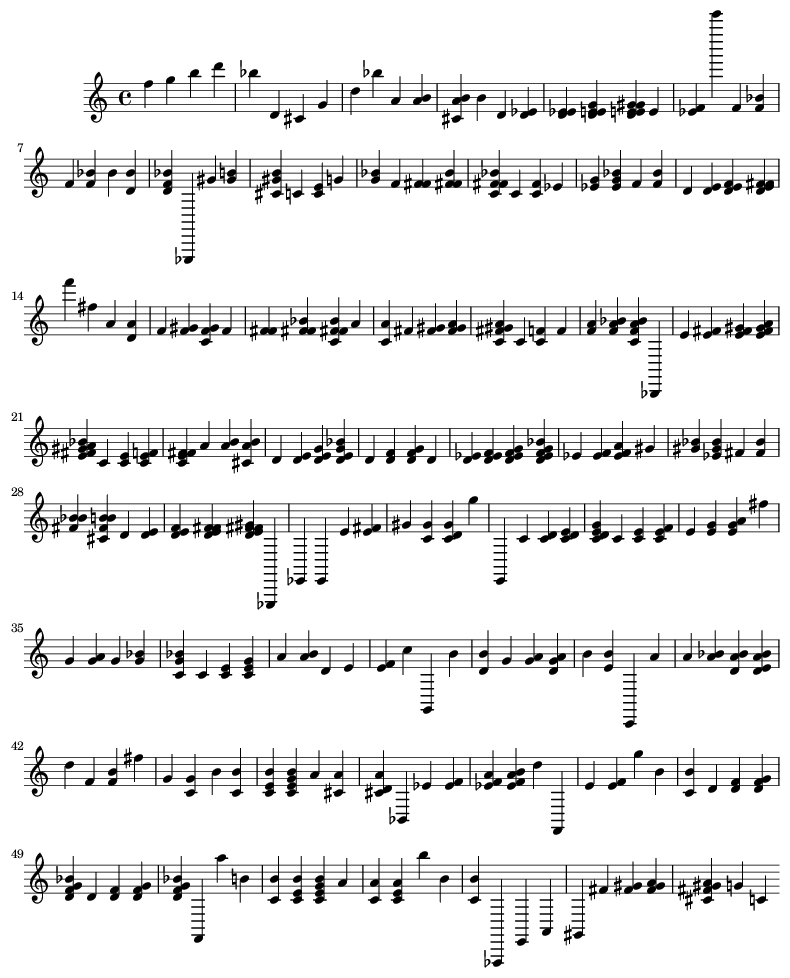

Generated song at temperature 2.0:


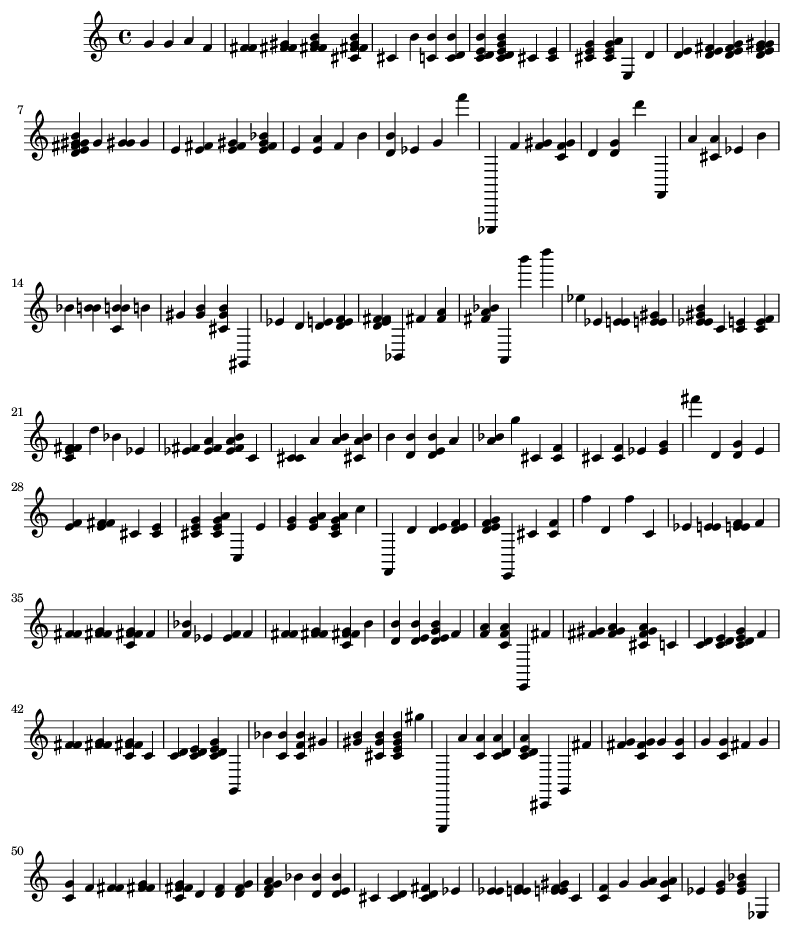

Generated song at temperature 2.5:


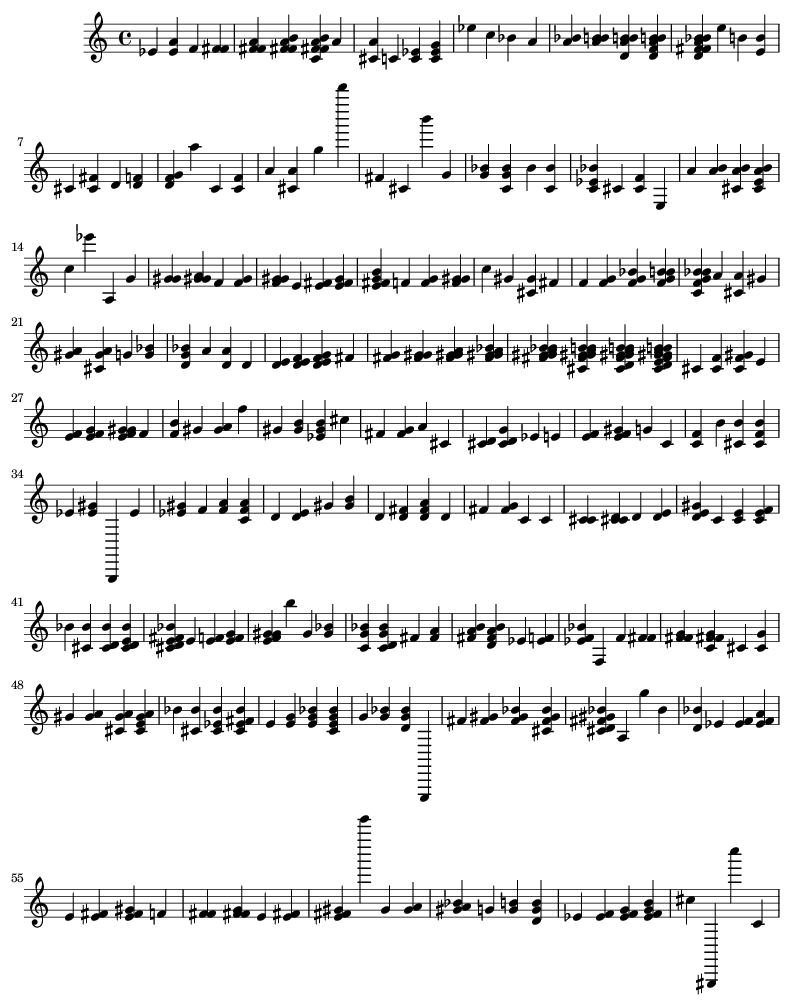

Generated song at temperature 3.0:


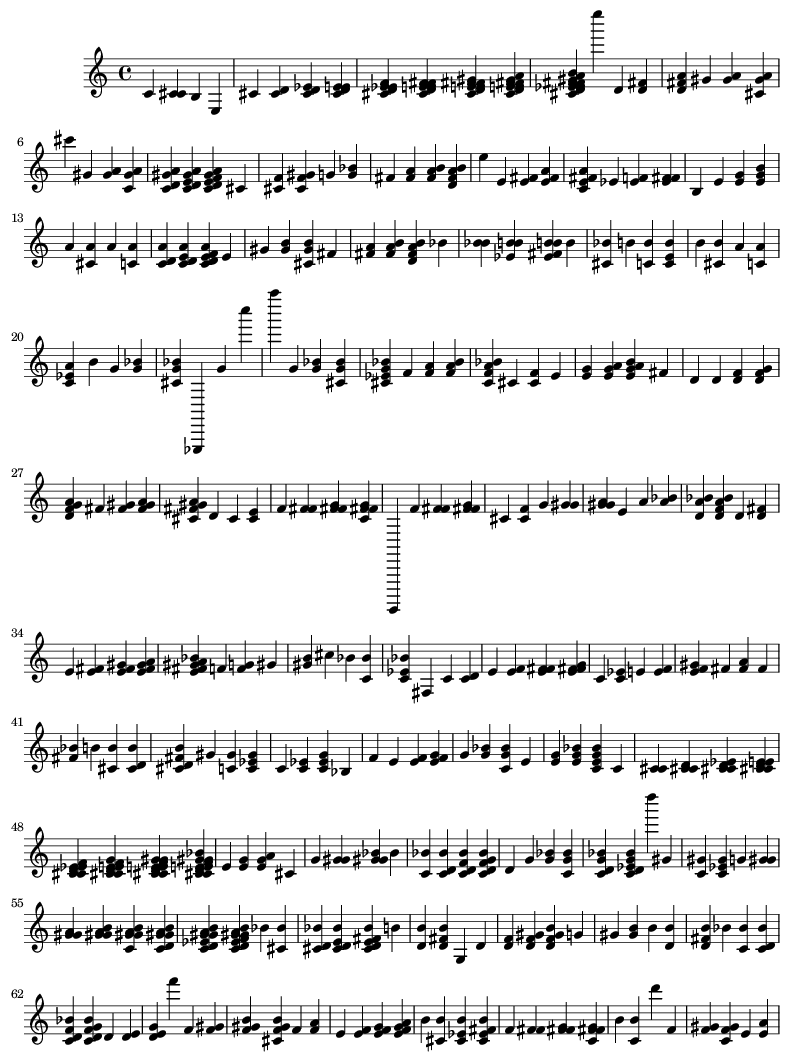

In [27]:
for temp in gru_temperatures:
    print(f"Generated song at temperature {temp}:")
    notes[temp].write('midi', f'songs/gru/GRU_t{temp}.mid')
    show(notes[temp])

### Simple RNN Model

In [28]:
rnn = keras.Sequential([
    layers.SimpleRNN(128),
    layers.Dense(len(unique_corpus), activation = "softmax")
])

optimizer = keras.optimizers.Nadam(learning_rate = 0.01)

rnn_model = keras.Sequential([embed, rnn])
rnn_model.compile(loss = "sparse_categorical_crossentropy", optimizer = optimizer, metrics = ["accuracy"])
rnn_model.fit(x_train, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_valid, y_valid), callbacks = [es, lr])

Epoch 1/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.3518 - loss: 2.9011 - val_accuracy: 0.2058 - val_loss: 3.7937 - learning_rate: 0.0100
Epoch 2/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.2342 - loss: 3.6106 - val_accuracy: 0.2767 - val_loss: 3.3285 - learning_rate: 0.0100
Epoch 3/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.2862 - loss: 3.3080 - val_accuracy: 0.2900 - val_loss: 3.3040 - learning_rate: 0.0100
Epoch 4/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.2909 - loss: 3.2781 - val_accuracy: 0.2379 - val_loss: 3.6178 - learning_rate: 0.0100
Epoch 5/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.2513 - loss: 3.4824 - val_accuracy: 0.2755 - val_loss: 3.4072 - learning_rate: 0.0100
Epoch 6/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.2736 - loss: 3.3615 - val_accuracy: 0.2560 - val_loss: 3.4150 - learning_rate: 0.0100
Epoch 7/40
1135/1135 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accura

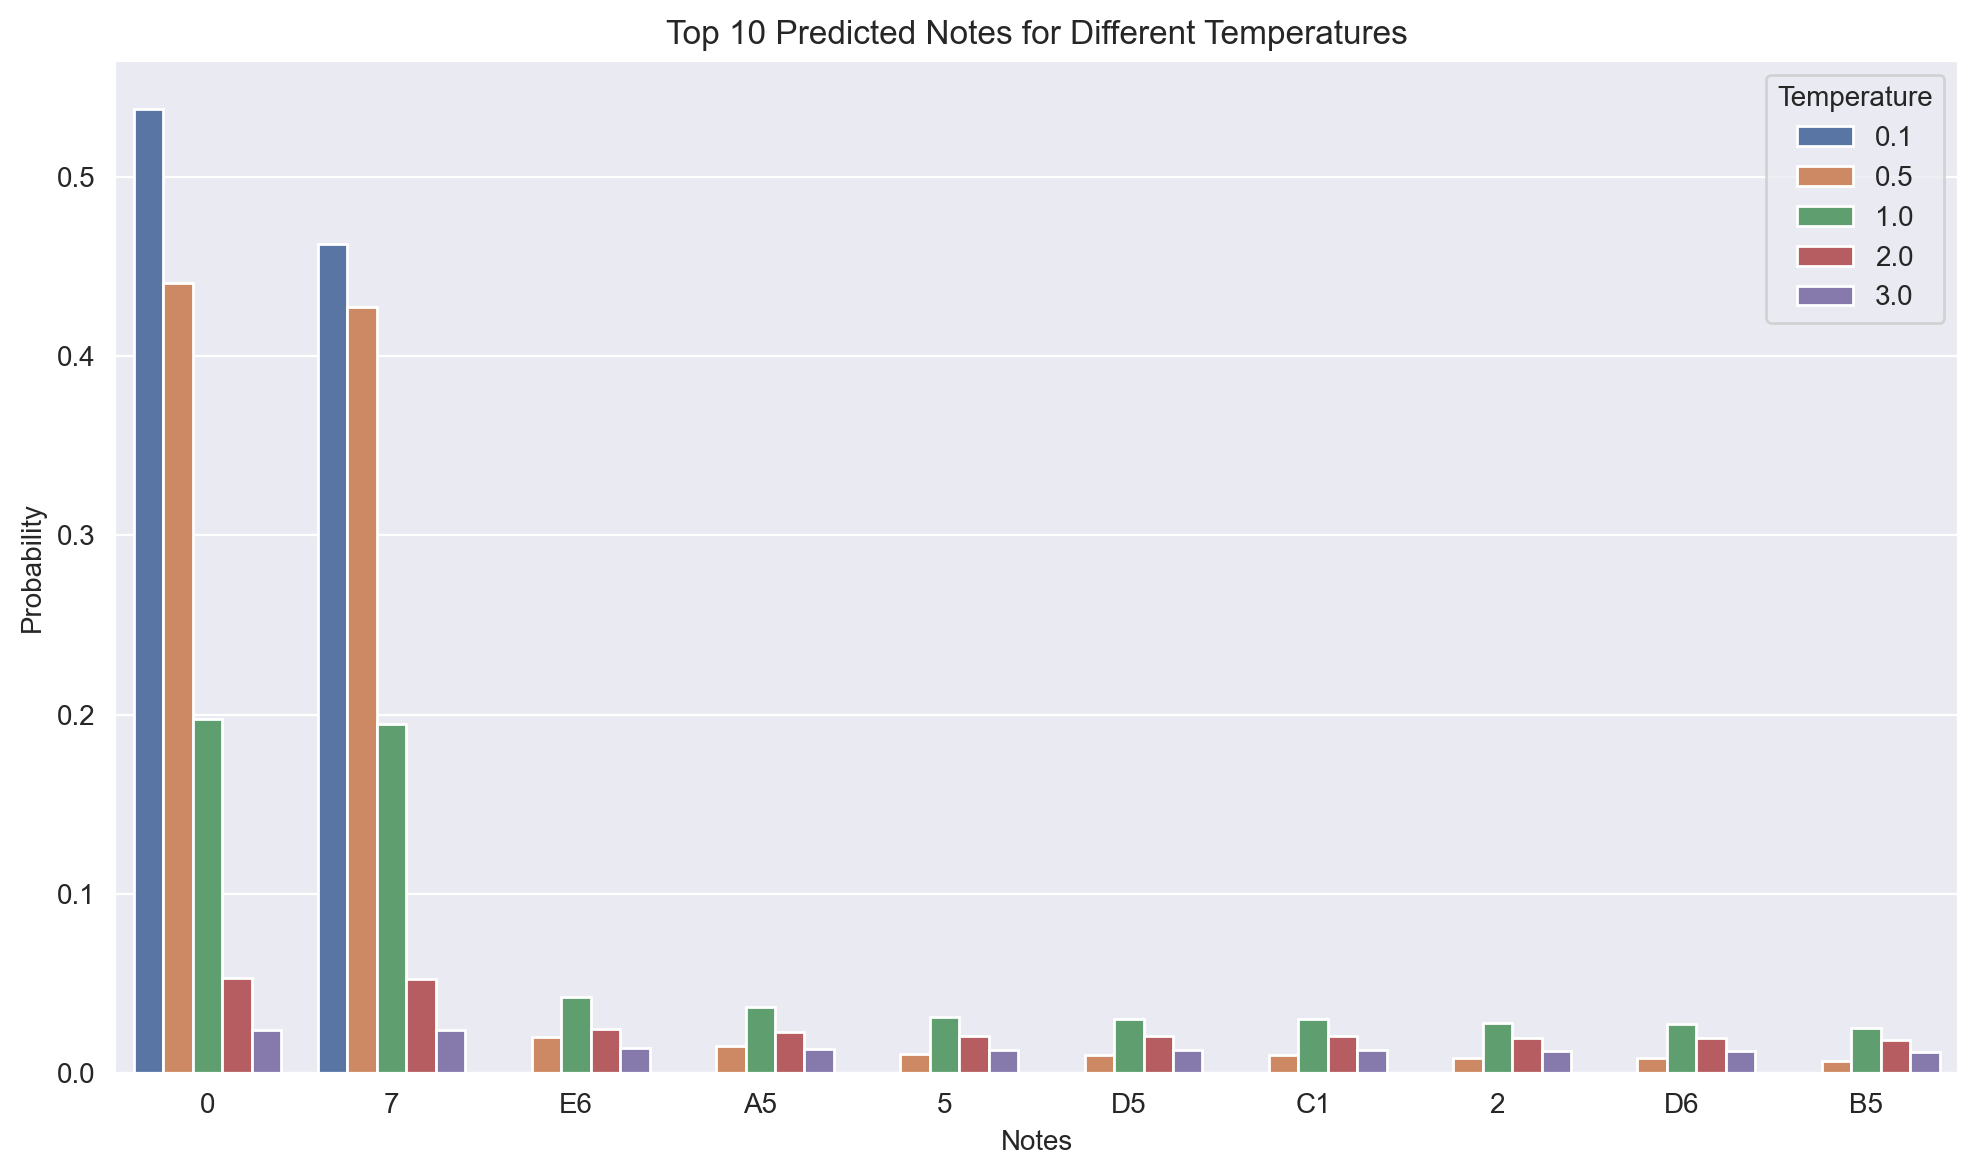

In [33]:
rnn_temperatures = [0.1, 0.5, 1.0, 2.0, 3.0]
plot_probabilities(rnn_model, unique_corpus, top_n=10, note_idx=0, temperatures=rnn_temperatures)

In [36]:
songs = {}
notes = {}
for temp in rnn_temperatures:
    song, note_stream = song_generator(rnn_model, x_valid, song_len=100, seq_length=40, notes_map=reverse_mapping, temperature=temp)
    songs[temp] = song
    notes[temp] = note_stream
    print(f"Generated song at temperature {temp}.")

Generated song at temperature 0.1.
Generated song at temperature 0.5.
Generated song at temperature 1.0.
Generated song at temperature 2.0.
Generated song at temperature 3.0.


Generated song at temperature 0.1:


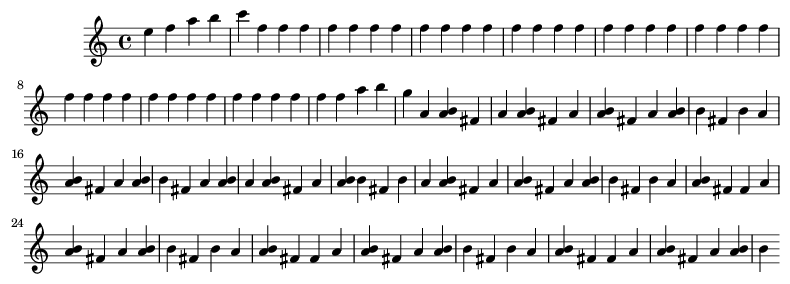

Generated song at temperature 0.5:


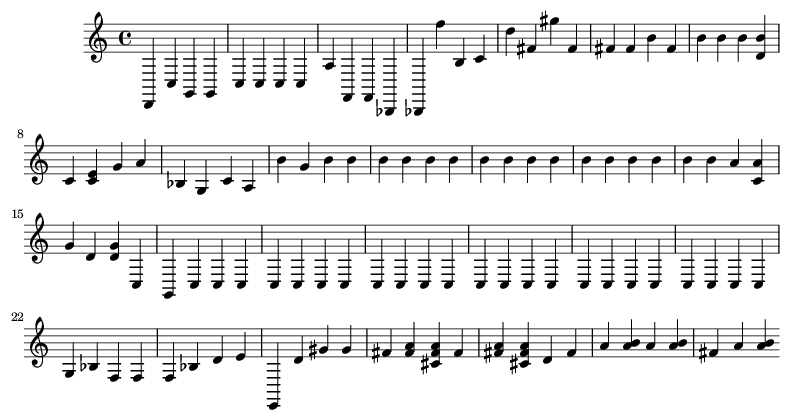

Generated song at temperature 1.0:


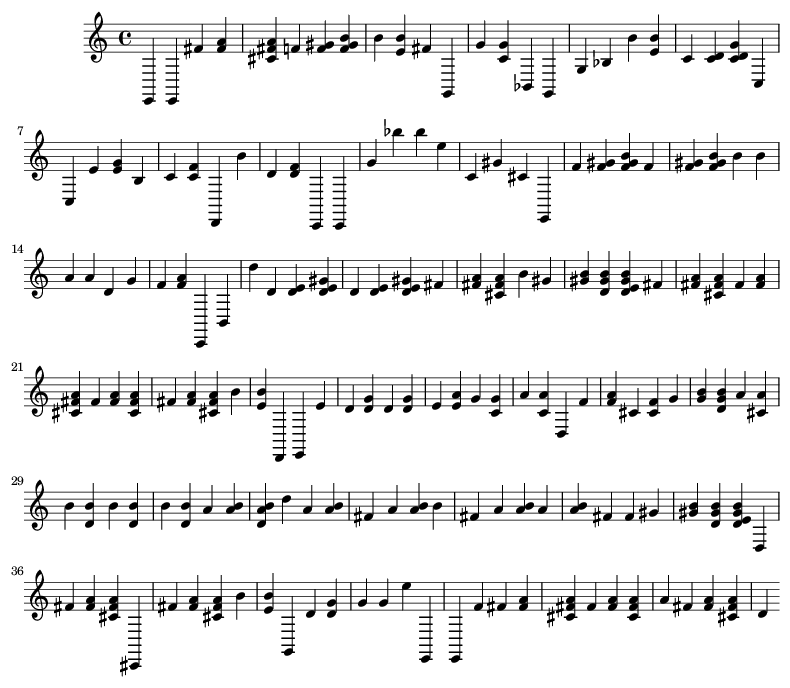

Generated song at temperature 2.0:


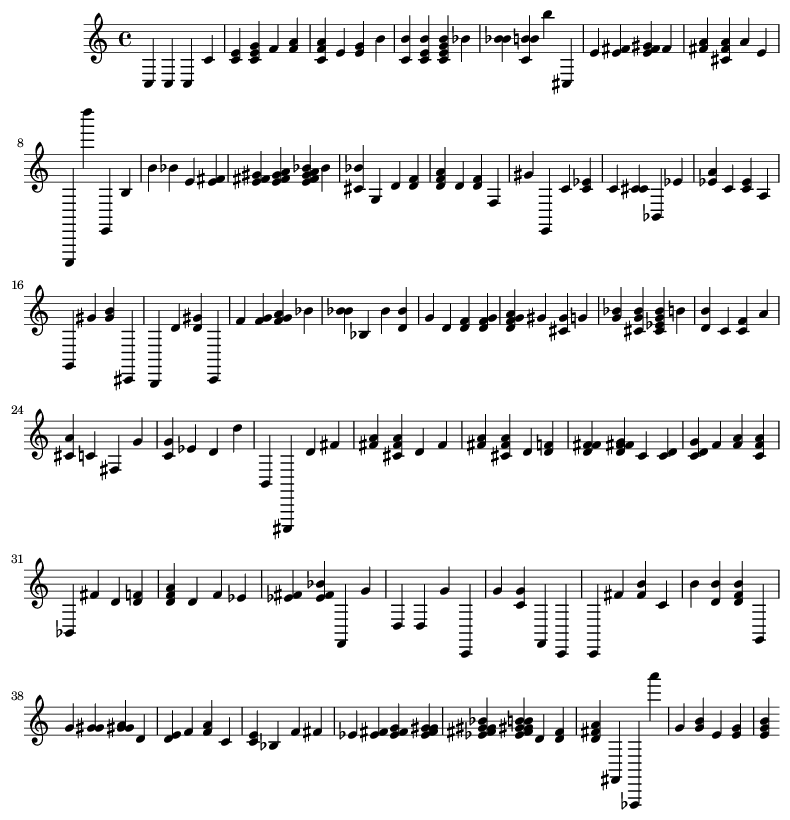

Generated song at temperature 3.0:


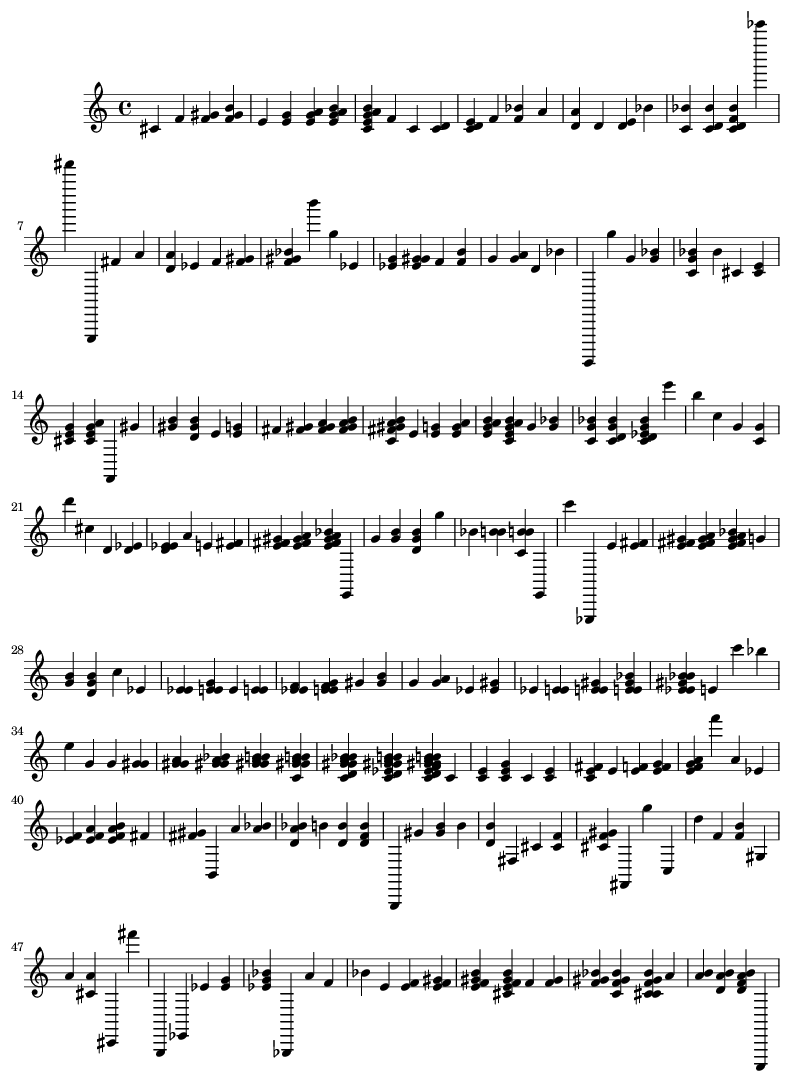

In [37]:
for temp in rnn_temperatures:
    print(f"Generated song at temperature {temp}:")
    notes[temp].write('midi', f'songs/rnn/RNN_t{temp}.mid')
    show(notes[temp])

## Conclusion

We built and trained three different RNN architectures (LSTM, GRU, and Simple RNN) to compose music. The models were trained on a combined corpus of Lofi and Ocarina of Time MIDI files. <br>
 The generated music varied based on the temperature parameter, which influenced the spectrum of notes that it would realistically use. Getting some good songs out of the models was unpredictable and felt a bit like gambling. <br>
 Comparing the performance of the models in composing music is really subjective, so there isn't much to comment on that besides the feel of the generated music. <br>
 They are all fun to experiment with, but the songs are quite rough. They feel unpolished, and like they jump around a lot especially at high temperatures. This is why we decided to try low temperatures as well, despite the already skewed probabilities. Lower temperatures produced more predictable and repetitive music, which in this case felt more coherent. <br>
 Overall, this was a fun exercise in using RNNs for music generation, and there is definitely room for improvement in future iterations.